In [ ]:
#STEP-1 Importing all the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
# STEP-2 loading the CSV dataset of Cars
data = pd.read_csv("/content/Car_Evaluation Original Dataset.csv")
data.head()
# giving standard names to the columns
data.columns = ['buying','maint','doors','persons','lug_boot','safety','class']
print(data.columns)

Index(['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class'], dtype='object')


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   int64 
dtypes: int64(1), object(6)
memory usage: 94.6+ KB
None
             class
count  1728.000000
mean      0.414931
std       0.740700
min       0.000000
25%       0.000000
50%       0.000000
75%       1.000000
max       3.000000
buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64


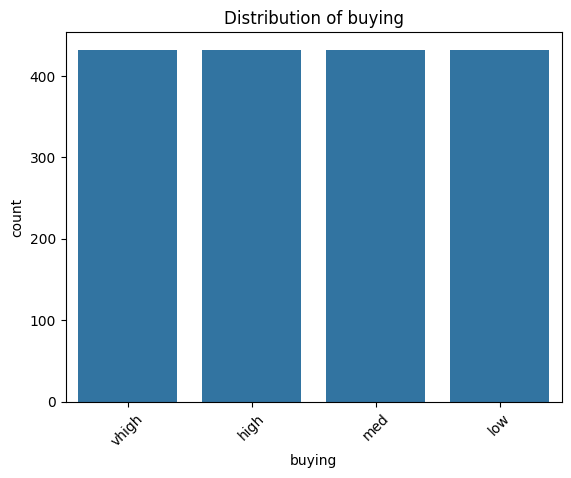

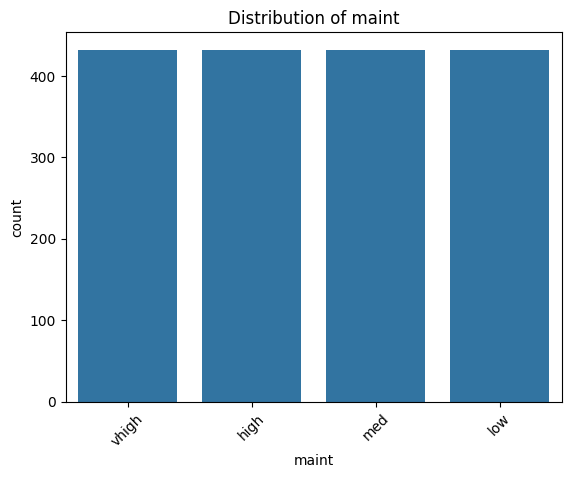

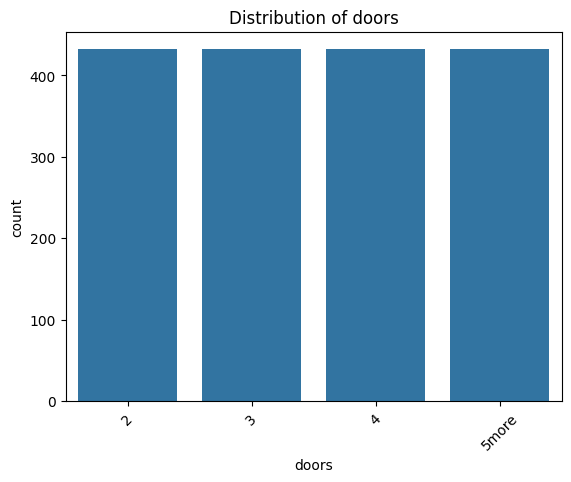

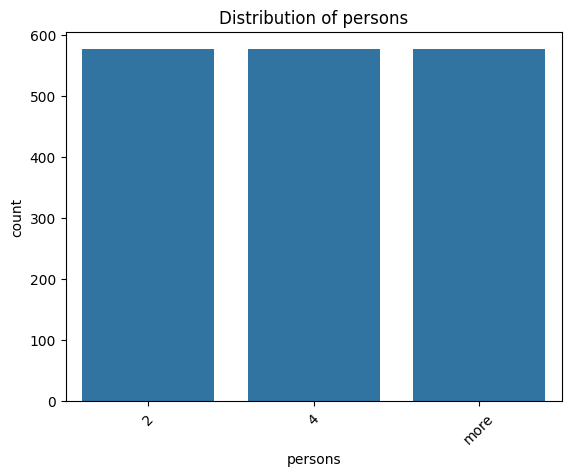

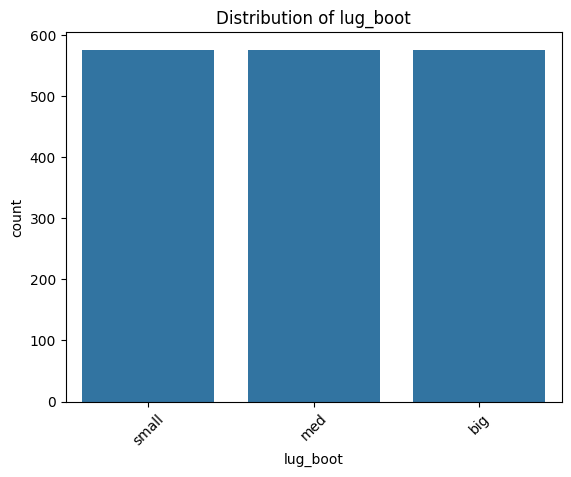

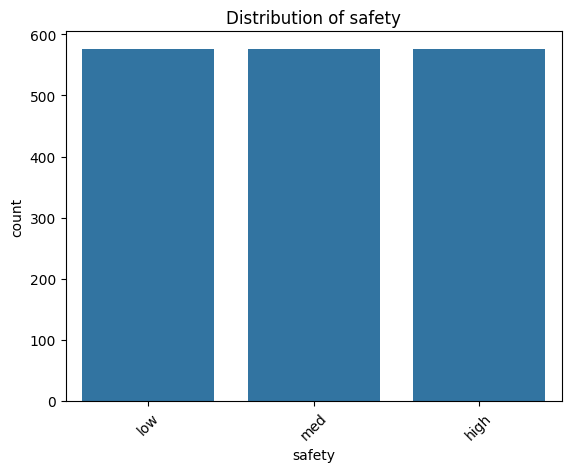

In [ ]:
# STEP-3 EDA
print(data.info())
print(data.describe())

print(data.isnull().sum())

# Feature wise Distribution
features = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']

for col in features:
    plt.figure()
    sns.countplot(x=col, data=data)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()





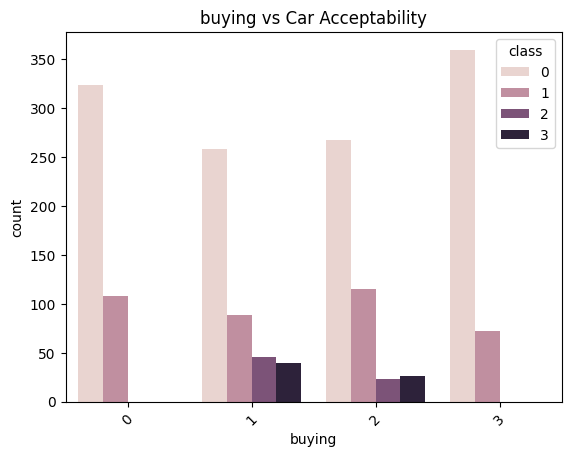

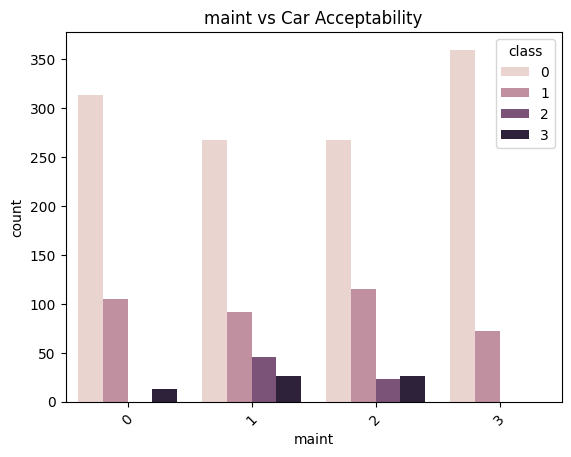

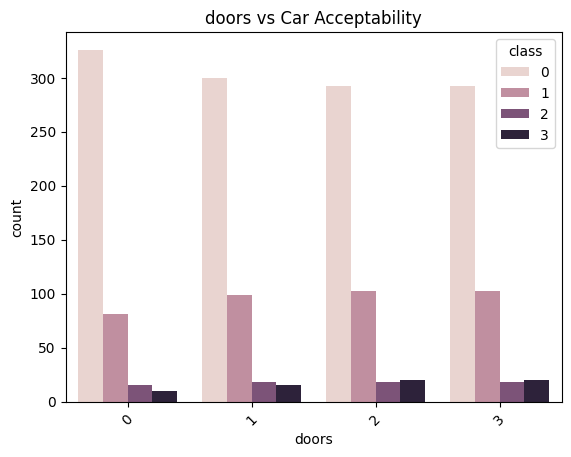

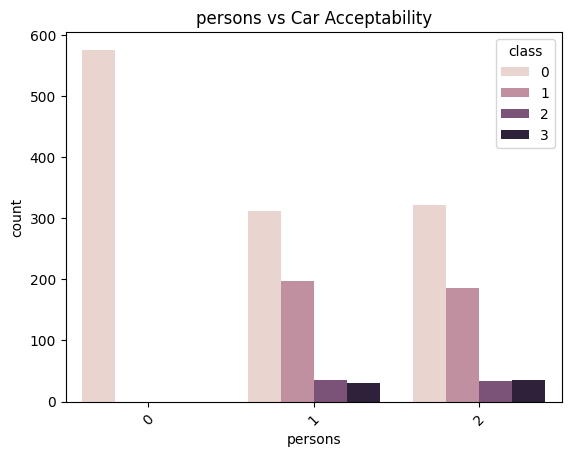

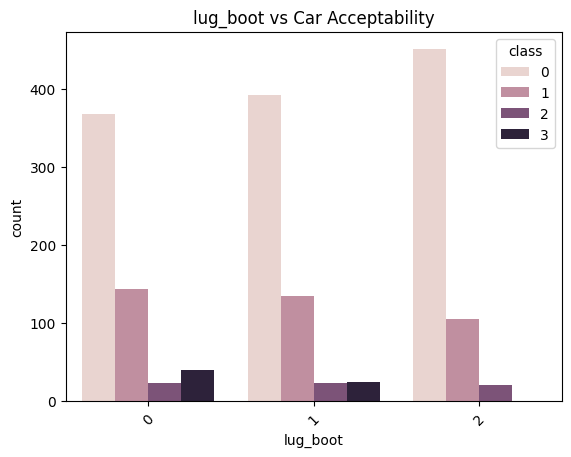

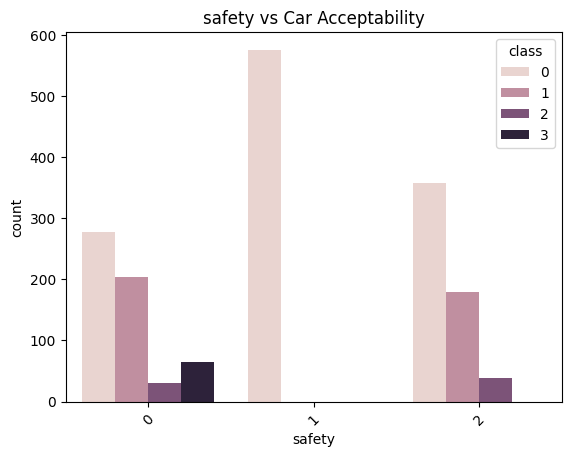

In [ ]:
# relation with the target object
for col in features:
    plt.figure()
    sns.countplot(x=col, hue='class', data=data)
    plt.title(f"{col} vs Car Acceptability")
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
# STEP-3 data preprocessing(encoding the categorical data)
le = LabelEncoder()
for col in data.columns:
    data[col] = le.fit_transform(data[col])
data.head()
print("\nEncoded Data:")
print(data.head())



Encoded Data:
   buying  maint  doors  persons  lug_boot  safety  class
0       3      3      0        0         2       1      0
1       3      3      0        0         2       2      0
2       3      3      0        0         2       0      0
3       3      3      0        0         1       1      0
4       3      3      0        0         1       2      0


In [ ]:
# STEP-4 Split the data
X = data.drop('class', axis=1)
y = data['class']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

In [ ]:
# STEP-5 CLASSIFICATION Using DESICISON TREE CLASSIFIER
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
print("\n Model Prediction:", y_pred_dt)
print("\nDecision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))



 Model Prediction: [0 1 0 1 0 1 0 0 0 0 1 1 1 0 0 0 0 0 0 1 0 1 1 0 1 0 0 0 0 0 1 0 0 0 1 1 2
 0 0 0 0 0 1 1 2 1 0 0 0 0 0 0 1 0 0 0 0 0 0 2 0 1 0 0 1 3 0 1 1 0 0 0 0 0
 2 3 0 0 0 0 3 0 0 1 3 1 0 1 3 1 0 2 0 0 0 2 0 0 0 1 0 0 0 0 2 2 1 0 0 1 0
 0 0 0 0 1 2 0 0 0 0 2 0 1 1 0 2 0 0 0 0 0 1 0 0 1 0 3 0 0 0 1 1 1 0 1 0 0
 0 0 1 3 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 1 3 1 0 1 0 0 1 0 0 0 0 1 0 0 0 2
 1 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 0 2 0 0 0 2 0 0 0 0 1 0 0 1 0 0 0 2 3 0
 0 1 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 1 0 0 0 0 0 1 3 0 0 0 1 0 0 3 0 0 1 1 0 1 0 1 1 0 0 1 2 3 1 1 0 0 0 0 3
 1 1 0 0 0 0 3 0 0 0 0 1 0 0 3 1 1 0 0 1 1 1 0 1 1 0 0 0 0 0 0 1 0 0 0 0 1
 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 3 0 0 0 0 1 0 1 0 0 0 1
 0 1 2 2 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0
 0 3 0 1 0 0 1 1 0 3 0 1 0 2 0 1 1 0 0 1 0 1 0 2 0 0 0 1 1 1 1 0 1 0 1 0 0
 1 2 0 1 1 1 0 3 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 2 0 0 0 0 0 1 0 0 3 0 0
 0 0 


Feature Importance:

    Feature  Importance
5    safety    0.249003
1     maint    0.213208
0    buying    0.194720
3   persons    0.173240
4  lug_boot    0.115269
2     doors    0.054559


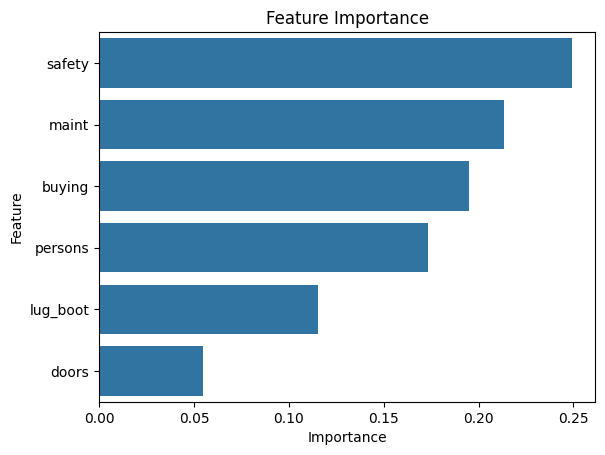

In [ ]:
# STEP- 6 Feature importance
feature_importance = dt_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance:\n")
print(importance_df)

plt.figure()
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title("Feature Importance")
plt.show()


Model Comparison:
            Model  Accuracy
0  Decision Tree  0.971098
1  Random Forest  0.965318
2            KNN  0.867052


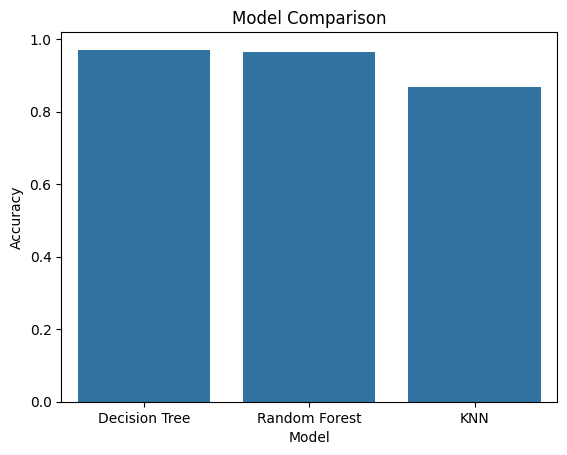

In [ ]:
# STEP-7 MODEL COMPARISONS
# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_acc = accuracy_score(y_test, dt.predict(X_test))

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test))

# KNN
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
knn_acc = accuracy_score(y_test, knn.predict(X_test))

# Results
results = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'KNN'],
    'Accuracy': [dt_acc, rf_acc, knn_acc]
})

print("\nModel Comparison:\n", results)

plt.figure()
sns.barplot(x='Model', y='Accuracy', data=results)
plt.title("Model Comparison")
plt.show()

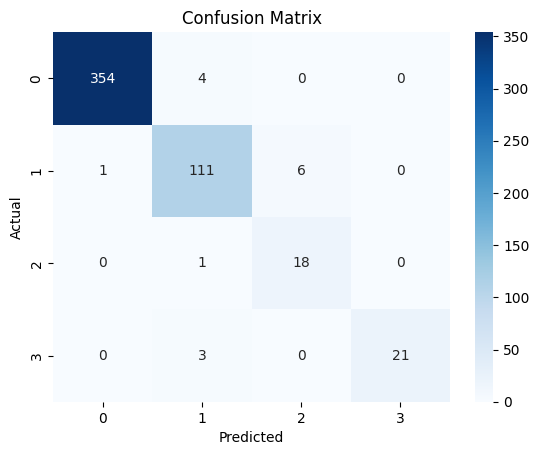

In [ ]:
# STEP-8 Creating a confusion matrix
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

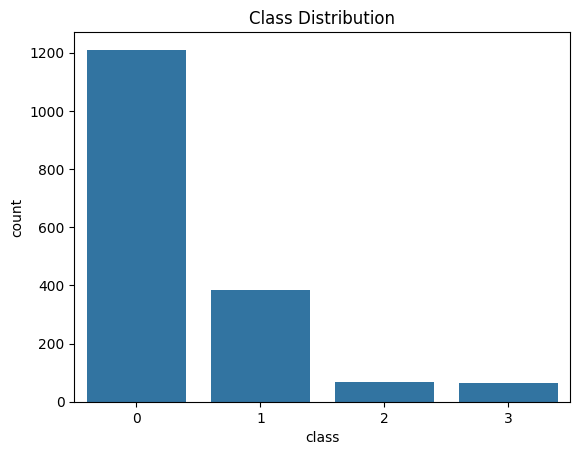

In [ ]:
# Extra VisualizationCheck Class Distribution
plt.figure()
sns.countplot(x='class', data=data)
plt.title("Class Distribution")
plt.show()